# Análisis de costos e inventario de refacciones de refrigeración

**Autor:** Kenji Teramoto
**Herramientas:** Python · pandas · matplotlib

---

## Contexto

En una operación de servicio de refrigeración, las **refacciones** son el segundo costo más grande
después de la mano de obra, y su disponibilidad determina si un servicio se cierra a tiempo o no.
Comprar de más inmoviliza dinero; comprar de menos genera quiebres de stock que paran servicios.

Este proyecto analiza **2,124 movimientos de inventario** de un año, en cinco bases regionales,
para responder:

> **¿En qué refacciones se concentra el gasto, y dónde se están produciendo los quiebres de stock
> que frenan la operación?**

## Por qué importa

En un proyecto anterior encontré que los servicios que requieren refacción tardan más del doble
en cerrarse. Este análisis busca el otro lado del problema: **qué piezas conviene tener siempre
en stock** para evitar esos retrasos, sin inflar el inventario completo.

## Nota sobre los datos

Dataset **sintético**, generado para este ejercicio. Replica la estructura y los problemas de
calidad de un sistema real de gestión de almacén: duplicados, capturas inconsistentes, nulos y
devoluciones mal registradas.

## 1. Carga e inspección

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('../datos/inventario_refacciones.csv')
print(f'Movimientos: {df.shape[0]}   Columnas: {df.shape[1]}')
df.head()

Movimientos: 2124   Columnas: 12


,id_movimiento,fecha,sku,refaccion,categoria,region,cantidad,costo_unitario,costo_total,lead_time_dias,critica,hubo_stockout
0,MOV-00472,02/01/2025,REF-112,Capacitor de arranque,Electrico,Centro,2.0,252.61,505.22,4,No,False
1,MOV-01366,29/04/2025,REF-106,Termostato digital,Control,Sureste,3.0,598.76,1796.28,5,No,False
2,MOV-01961,25/08/2025,REF-104,Gas refrigerante R-134a,Refrigerante,Bajio,3.0,941.28,2823.84,4,Si,False
3,MOV-00931,21/09/2025,REF-103,Compresor 3/4 HP,Compresor,Bajio,2.0,8070.54,16141.08,18,Si,False
4,MOV-00752,16/07/2025,REF-114,Valvula de expansion,Control,Bajio,2.0,1295.17,2590.34,11,No,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_movimiento   2124 non-null   str    
 1   fecha           2124 non-null   str    
 2   sku             2124 non-null   str    
 3   refaccion       2124 non-null   str    
 4   categoria       2124 non-null   str    
 5   region          2124 non-null   str    
 6   cantidad        2105 non-null   float64
 7   costo_unitario  2086 non-null   float64
 8   costo_total     2124 non-null   float64
 9   lead_time_dias  2124 non-null   int64  
 10  critica         2124 non-null   str    
 11  hubo_stockout   2124 non-null   bool   
dtypes: bool(1), float64(3), int64(1), str(7)
memory usage: 184.7 KB


### Diccionario de datos

| Columna | Descripción |
|---|---|
| `id_movimiento` | Identificador de la salida de almacén |
| `fecha` | Fecha del movimiento |
| `sku` / `refaccion` | Clave y nombre de la pieza |
| `categoria` | Familia de la refacción |
| `region` | Base regional |
| `cantidad` | Unidades consumidas |
| `costo_unitario` / `costo_total` | Costo en pesos |
| `lead_time_dias` | Días de reabastecimiento del proveedor |
| `critica` | Si es una pieza crítica para el servicio |
| `hubo_stockout` | Si no había pieza disponible al pedirla |

## 2. Diagnóstico de calidad de datos

In [3]:
print('Duplicados exactos:', df.duplicated().sum())
print('\nNulos:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nRegiones (crudas):', sorted(df.region.unique()))
print('\nCantidades negativas (devoluciones mal capturadas):', (df.cantidad < 0).sum())

Duplicados exactos: 21

Nulos:
cantidad          19
costo_unitario    38
dtype: int64

Regiones (crudas): [' Bajio', ' Centro', ' Norte', ' Occidente', ' Sureste', 'BAJIO', 'Bajio', 'CENTRO', 'Centro', 'NORTE', 'Norte', 'OCCIDENTE', 'Occidente', 'SURESTE', 'Sureste']

Cantidades negativas (devoluciones mal capturadas): 11


Cuatro problemas: duplicados, nulos en `costo_unitario` y `cantidad`, la región escrita de varias
formas (`CENTRO`, ` Centro`), y **cantidades negativas** que son devoluciones mal registradas y
distorsionarían el consumo.

## 3. Limpieza

In [4]:
d = df.copy()
n0 = len(d)

d = d.drop_duplicates()
d['region'] = d['region'].str.strip().str.title()
d['fecha'] = pd.to_datetime(d['fecha'], format='%d/%m/%Y')

# Descartar nulos en las variables de cálculo y cantidades no positivas
d = d.dropna(subset=['cantidad', 'costo_unitario'])
d = d[d['cantidad'] > 0]

# Recalcular costo_total para garantizar consistencia
d['costo_total'] = (d['cantidad'] * d['costo_unitario']).round(2)
d['mes'] = d['fecha'].dt.month

print(f'Registros: {n0} -> {len(d)} ({len(d)/n0:.1%} conservado)')
print(f'Gasto total anual analizado: ${d.costo_total.sum():,.0f} MXN')

Registros: 2124 -> 2035 (95.8% conservado)
Gasto total anual analizado: $9,558,590 MXN


## 4. ¿En qué se va el dinero?

### 4.1 Gasto por categoría

                  gasto  movimientos   pct
categoria                                 
Compresor     7170720.0          452  75.0
Refrigerante   923552.0          330  10.0
Ventilacion    517709.0          260   5.0
Control        490804.0          379   5.0
Electrico      259702.0          365   3.0
Sello          163054.0          159   2.0
Filtro          33049.0           90   0.0


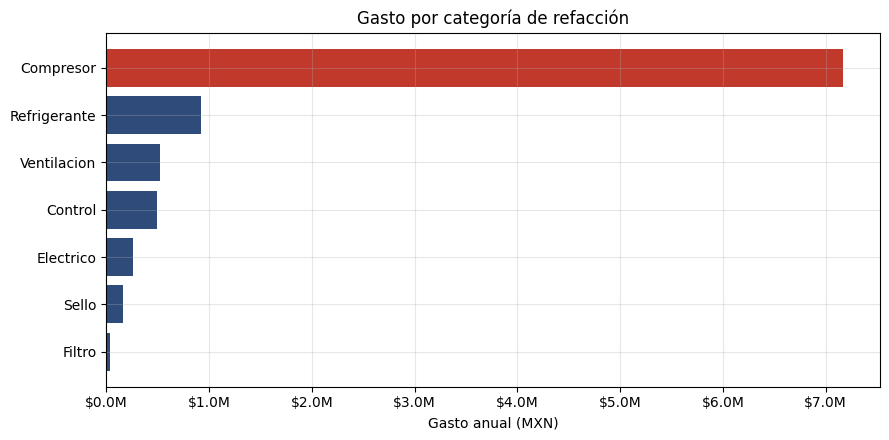

In [5]:
por_cat = d.groupby('categoria').agg(
    gasto=('costo_total', 'sum'),
    movimientos=('id_movimiento', 'count')
).sort_values('gasto', ascending=False)
por_cat['pct'] = (por_cat.gasto / por_cat.gasto.sum() * 100).round(1)
print(por_cat.round(0))

fig, ax = plt.subplots(figsize=(9, 4.5))
colores = ['#C0392B' if i == 0 else '#2E4B7A' for i in range(len(por_cat))]
ax.barh(por_cat.index[::-1], por_cat.gasto[::-1], color=colores[::-1])
ax.set_xlabel('Gasto anual (MXN)'); ax.set_title('Gasto por categoría de refacción')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout(); plt.savefig('../imagenes/01_categorias.png', dpi=110, bbox_inches='tight')
plt.show()

Los **compresores** dominan por completo el gasto. No es sorpresa —son la pieza más cara—
pero pone número a la intuición: la mayor parte del presupuesto de refacciones vive en una sola familia.

### 4.2 Análisis de Pareto: ¿la regla del 80/20 aplica?

In [6]:
pareto = d.groupby('refaccion').costo_total.sum().sort_values(ascending=False)
pareto_df = pd.DataFrame({'gasto': pareto})
pareto_df['pct'] = (pareto_df.gasto / pareto_df.gasto.sum() * 100).round(1)
pareto_df['acumulado'] = pareto_df.pct.cumsum().round(1)
pareto_df.head(8)

,gasto,pct,acumulado
refaccion,,,
Compresor 3/4 HP,3082522.07,32.2,32.2
Compresor 1/2 HP,2309695.01,24.2,56.4
Compresor 1/3 HP,1778502.61,18.6,75.0
Gas refrigerante R-404a,539273.86,5.6,80.6
Gas refrigerante R-134a,384277.97,4.0,84.6
Valvula de expansion,240343.45,2.5,87.1
Ventilador evaporador,183648.50,1.9,89.0
Ventilador condensador,183424.00,1.9,90.9


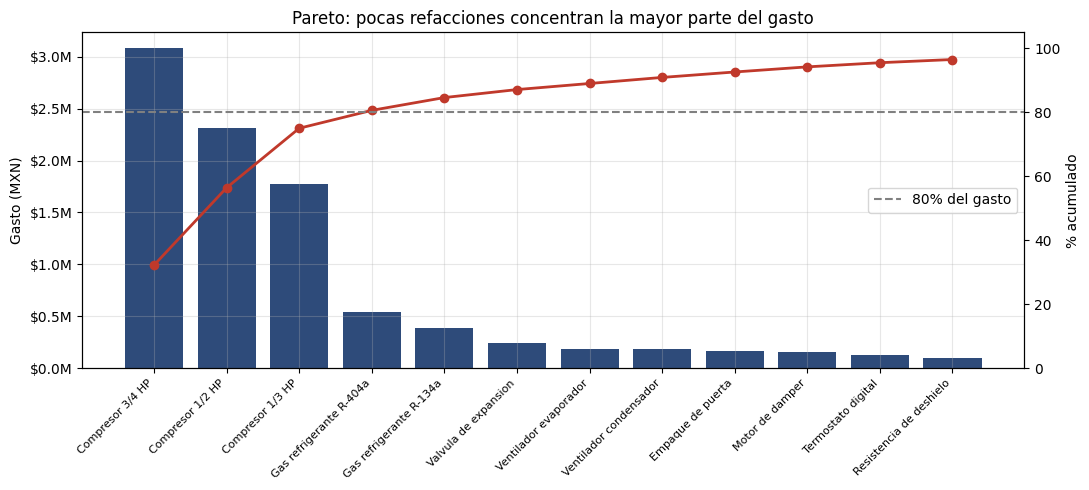

4 refacciones concentran el 80% del gasto, de 18 en total.


In [7]:
fig, ax1 = plt.subplots(figsize=(11, 5))
top = pareto_df.head(12)
ax1.bar(range(len(top)), top.gasto, color='#2E4B7A')
ax1.set_xticks(range(len(top)))
ax1.set_xticklabels(top.index, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Gasto (MXN)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(range(len(top)), top.acumulado, color='#C0392B', marker='o', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1.5, label='80% del gasto')
ax2.set_ylabel('% acumulado'); ax2.set_ylim(0, 105); ax2.grid(False); ax2.legend(loc='center right')
ax1.set_title('Pareto: pocas refacciones concentran la mayor parte del gasto')
plt.tight_layout(); plt.savefig('../imagenes/02_pareto.png', dpi=110, bbox_inches='tight')
plt.show()

n80 = (pareto_df.acumulado <= 80).sum() + 1
print(f'{n80} refacciones concentran el 80% del gasto, de {len(pareto_df)} en total.')

**Hallazgo principal.** El Pareto es clarísimo: los **tres tipos de compresor** representan el
**75% del gasto**, y con solo **cinco piezas** se llega al **85%**.

Esto cambia cómo se gestiona el almacén. No hace falta controlar con lupa las 18 refacciones:
basta con vigilar de cerca esas cinco para controlar la mayor parte del presupuesto.

## 5. El problema de los quiebres de stock

In [8]:
stockout_global = d.hubo_stockout.mean()
print(f'Tasa global de quiebres de stock: {stockout_global:.1%}')

por_critica = d.groupby('critica').agg(
    movimientos=('id_movimiento', 'count'),
    tasa_stockout=('hubo_stockout', 'mean')
)
por_critica['tasa_stockout'] = (por_critica.tasa_stockout * 100).round(1)
print(por_critica)

Tasa global de quiebres de stock: 13.4%
         movimientos  tasa_stockout
critica                            
No              1094            9.4
Si               941           18.0


Uno de cada siete pedidos se encuentra sin pieza disponible. Y las **refacciones críticas**
—las que detienen un servicio— fallan **el doble** que las no críticas. Es el peor escenario posible:
las piezas más importantes son las que más se agotan.

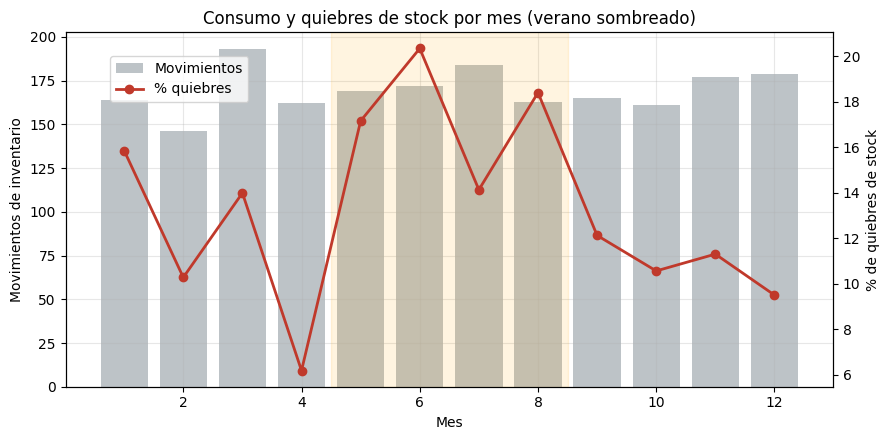

     movimientos  tasa_stockout
mes                            
1            164           15.9
2            146           10.3
3            193           14.0
4            162            6.2
5            169           17.2
6            172           20.3
7            184           14.1
8            163           18.4
9            165           12.1
10           161           10.6
11           177           11.3
12           179            9.5


In [9]:
por_mes = d.groupby('mes').agg(
    movimientos=('id_movimiento', 'count'),
    tasa_stockout=('hubo_stockout', 'mean')
)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(por_mes.index, por_mes.movimientos, color='#BDC3C7', label='Movimientos')
ax1.set_xlabel('Mes'); ax1.set_ylabel('Movimientos de inventario')
ax2 = ax1.twinx()
ax2.plot(por_mes.index, por_mes.tasa_stockout * 100, color='#C0392B', marker='o', linewidth=2, label='% quiebres')
ax2.set_ylabel('% de quiebres de stock'); ax2.grid(False)
ax2.axvspan(4.5, 8.5, alpha=0.12, color='orange')
ax1.set_title('Consumo y quiebres de stock por mes (verano sombreado)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout(); plt.savefig('../imagenes/03_estacionalidad.png', dpi=110, bbox_inches='tight')
plt.show()
print(por_mes.assign(tasa_stockout=(por_mes.tasa_stockout*100).round(1)))

Los quiebres se concentran de **mayo a agosto**, que es justo cuando más se consume.
Coincide con el hallazgo del proyecto anterior: en verano los equipos fallan más, el consumo de
compresores y gas sube, y el almacén no alcanza a reabastecerse. La operación se queda sin piezas
en el peor momento.

## 6. ¿Dónde inmoviliza más dinero el inventario?

In [10]:
por_region = d.groupby('region').agg(
    gasto=('costo_total', 'sum'),
    tasa_stockout=('hubo_stockout', 'mean')
).sort_values('gasto', ascending=False)
por_region['tasa_stockout'] = (por_region.tasa_stockout * 100).round(1)
por_region['gasto'] = por_region.gasto.round(0)
por_region

,gasto,tasa_stockout
region,,
Centro,3212609.0,11.3
Norte,2053347.0,16.0
Bajio,1952487.0,13.7
Occidente,1501721.0,11.6
Sureste,838425.0,16.7


Centro concentra el mayor gasto (es la región con más operación), pero **Norte y Sureste**
combinan alto lead time con las tasas de quiebre más altas: están lejos, tardan en reabastecerse
y se quedan sin piezas con más frecuencia.

## 7. Tabla resumen

In [11]:
resumen = pd.DataFrame({
    'KPI': [
        'Movimientos analizados',
        'Gasto anual en refacciones',
        'Refacciones distintas (SKU)',
        'Refacciones que concentran el 80% del gasto',
        'Categoría de mayor gasto',
        'Tasa global de quiebres de stock',
        'Tasa de quiebre en piezas críticas',
        'Meses con más quiebres',
    ],
    'Valor': [
        f'{len(d):,}',
        f'${d.costo_total.sum():,.0f} MXN',
        f'{d.sku.nunique()}',
        f'{n80} piezas',
        f'{por_cat.index[0]} ({por_cat.pct.iloc[0]:.0f}% del gasto)',
        f'{stockout_global:.1%}',
        f'{por_critica.loc["Si","tasa_stockout"]:.0f}%',
        'Mayo a agosto (verano)',
    ]
})
resumen

,KPI,Valor
0,Movimientos analizados,"2,035"
1,Gasto anual en refacciones,"$9,558,590 MXN"
2,Refacciones distintas (SKU),18
3,Refacciones que concentran el 80% del gasto,4 piezas
4,Categoría de mayor gasto,Compresor (75% del gasto)
5,Tasa global de quiebres de stock,13.4%
6,Tasa de quiebre en piezas críticas,18%
7,Meses con más quiebres,Mayo a agosto (verano)


## 8. Conclusiones

**1. El gasto está hiperconcentrado.** Cinco refacciones —tres compresores y dos gases— explican
el 85% del presupuesto. Controlar esas cinco es controlar el gasto.

**2. Las piezas críticas son las que más se agotan.** Su tasa de quiebre (18%) duplica la de las
no críticas (9%). Es el peor patrón posible.

**3. Los quiebres se disparan en verano**, cuando más se necesitan las piezas, por el pico de fallas.

**4. Norte y Sureste son las bases más vulnerables:** mayor lead time y mayor tasa de quiebre.

---

## 9. Recomendaciones

| # | Acción | Fundamento |
|---|---|---|
| 1 | Aplicar control estricto de stock mínimo a las 5 refacciones del 80% del gasto | Concentran el presupuesto; ahí está el ahorro |
| 2 | Elevar el punto de reorden de las piezas críticas antes de verano | Duplican la tasa de quiebre justo en temporada alta |
| 3 | Aumentar inventario de seguridad de compresores en Norte y Sureste | Alto lead time + alta tasa de quiebre |
| 4 | Negociar lead time con el proveedor de compresores | Es la familia más cara y de reabastecimiento más lento |
| 5 | Corregir la captura de devoluciones (cantidades negativas) | Ensucian el consumo real y afectan la planeación |

---

## 10. Conexión con el análisis de servicios

Este proyecto complementa mi análisis de tiempos de respuesta. Allá encontré que los servicios
**con refacción tardan más del doble**; aquí identifico **exactamente qué cinco piezas** mantener
en stock para evitar esos retrasos. Juntos forman una recomendación accionable: no se trata de
inflar todo el inventario, sino de blindar las cinco refacciones que mueven la operación.